### Library & Data import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

sns.set_style('darkgrid')

In [ ]:
!git clone "https://github.com/GeeksforgeeksDS/21-Days-21-Projects-Dataset"

Cloning into '21-Days-21-Projects-Dataset'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 18 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 1.40 MiB | 5.18 MiB/s, done.
Resolving deltas: 100% (2/2), done.


### Data Info

In [ ]:
df = pd.read_csv('/content/21-Days-21-Projects-Dataset/Datasets/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [ ]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,216,492,7769
top,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,1608,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN


In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


## General Overview-

### 1. Null values are in 5 features -  
  Director, Cast, Country, date_added, rating

### 2. type are 2 only - TV show, Movie

# **Data Cleaning**

In [ ]:
print("Can't determine the director or cast by any metrics, hence filling Unknown")

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

df.isnull().sum()

Can't determine the director or cast by any metrics, hence filling Unknown


,0
show_id,0
type,0
title,0
director,0
cast,0
country,507
date_added,10
release_year,0
rating,7
duration,0


In [ ]:
country_mode = df['country'].mode()[0]
print("Mode of country is ",country_mode)
df['country'] = df['country'].fillna(country_mode)
df.isnull().sum()

Mode of country is  United States


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,7
duration,0


In [ ]:
print("Missing values in date_added and rating are few, dropping it")

df.dropna(subset=['date_added', 'rating'], inplace=True)
df.isnull().sum()

Missing values in date_added and rating are few, dropping it


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# Data Transformation

In [ ]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...


In [ ]:
print("Transforming Date format")
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', dayfirst=False)

df.head(2)

Transforming Date format


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...


In [ ]:
print("Adding new year and month features")
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

df.head(2)

Adding new year and month features


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12


In [ ]:
print(df.dtypes)

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int32
month_added              int32
dtype: object


# EDA and Visualization

### Practice Q1- What is the distribution of content type?

In [ ]:
plt.figure(figsize=(8,6))
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      5372
TV Show    2398
Name: count, dtype: int64


<Figure size 800x600 with 0 Axes>

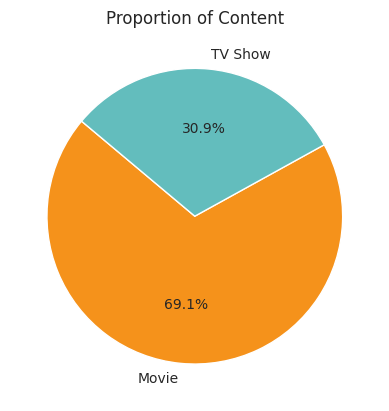

In [ ]:
plt.pie(type_counts, labels=type_counts.index, autopct = '%1.1f%%', startangle=140, colors=['#F5921B', '#63BDBD'])
plt.title('Proportion of Content')
plt.show()

### Outcome - More Movies are ther than TV Shows on Netflix

### Practice Q2- How has content been added over time?

In [ ]:
content_over_time_temp = df.groupby(['year_added', 'type']).size()
print(content_over_time_temp)

year_added  type   
2008        Movie         1
            TV Show       1
2009        Movie         2
2010        Movie         1
2011        Movie        13
2012        Movie         3
2013        Movie         6
            TV Show       5
2014        Movie        19
            TV Show       6
2015        Movie        58
            TV Show      30
2016        Movie       256
            TV Show     184
2017        Movie       861
            TV Show     361
2018        Movie      1255
            TV Show     429
2019        Movie      1497
            TV Show     656
2020        Movie      1312
            TV Show     697
2021        Movie        88
            TV Show      29
dtype: int64


In [ ]:
print(content_over_time_temp.unstack().fillna(0))

type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      0.0
2010           1.0      0.0
2011          13.0      0.0
2012           3.0      0.0
2013           6.0      5.0
2014          19.0      6.0
2015          58.0     30.0
2016         256.0    184.0
2017         861.0    361.0
2018        1255.0    429.0
2019        1497.0    656.0
2020        1312.0    697.0
2021          88.0     29.0


<Figure size 1400x800 with 0 Axes>

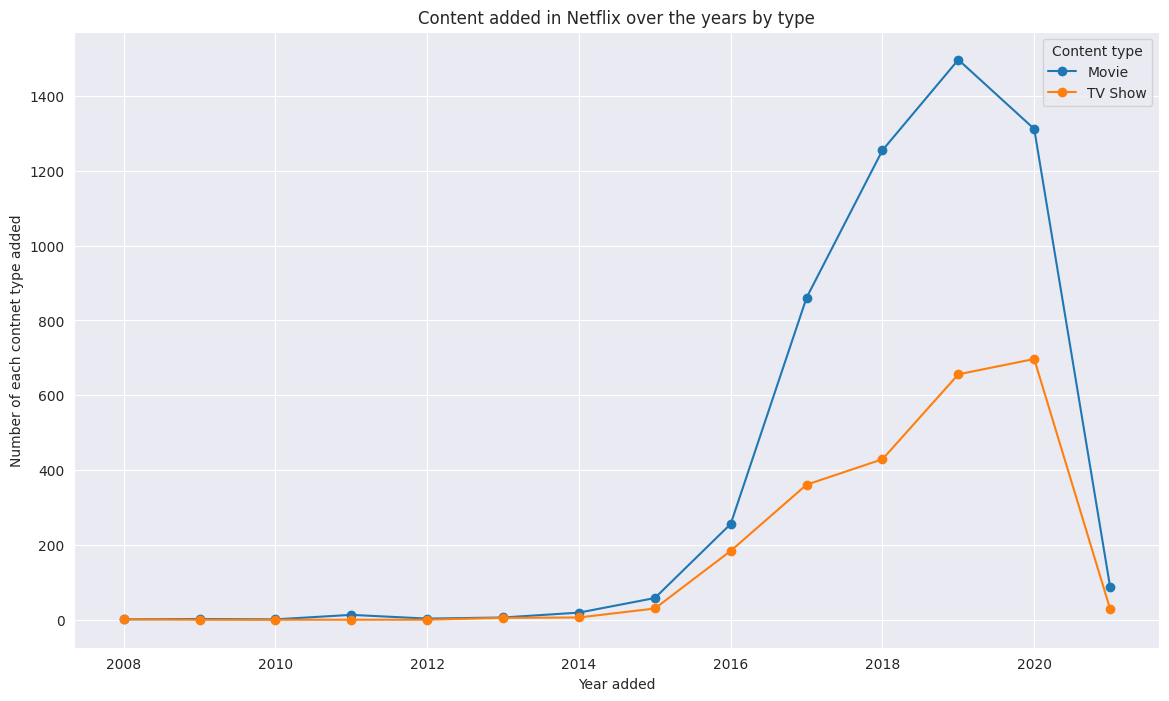

In [ ]:
content_over_time = content_over_time_temp.unstack().fillna(0)

plt.figure(figsize=(14,8))
content_over_time.plot(kind='line', marker='o', figsize=(14,8))
plt.title('Content added in Netflix over the years by type')
plt.xlabel('Year added')
plt.ylabel('Number of each contnet type added')
plt.legend(title='Content type')
plt.grid(True)
plt.show()

### Outcome - 2016 to 2021 the major content was added though Netflix started from 2008.

#### Also there is a significant dipfrom 1400+ to almost 0 after 2021 - COVID-19 effect

### Practice Q3- What are the most popular genres?

In [ ]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8


In [ ]:
genres_df = df.assign(genre = df['listed_in'].str.split(', ')).explode('genre')
genres_df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genre
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,International TV Shows
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,TV Dramas
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,TV Sci-Fi & Fantasy
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,Dramas
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,International Movies
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12,Horror Movies
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12,International Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11,Action & Adventure
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11,Independent Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11,Sci-Fi & Fantasy


In [ ]:
top_genres = genres_df['genre'].value_counts().reset_index()
print(top_genres)

                           genre  count
0           International Movies   2437
1                         Dramas   2105
2                       Comedies   1471
3         International TV Shows   1197
4                  Documentaries    786
5             Action & Adventure    721
6                      TV Dramas    703
7             Independent Movies    673
8       Children & Family Movies    532
9                Romantic Movies    531
10                   TV Comedies    517
11                     Thrillers    491
12                Crime TV Shows    426
13                      Kids' TV    411
14                    Docuseries    352
15             Romantic TV Shows    333
16               Stand-Up Comedy    329
17              Music & Musicals    321
18                 Horror Movies    312
19              British TV Shows    231
20                    Reality TV    222
21              Sci-Fi & Fantasy    218
22                 Sports Movies    196
23               Korean TV Shows    150


In [ ]:
top_genres.columns = ['genre', 'count']
print(top_genres)

                           genre  count
0           International Movies   2437
1                         Dramas   2105
2                       Comedies   1471
3         International TV Shows   1197
4                  Documentaries    786
5             Action & Adventure    721
6                      TV Dramas    703
7             Independent Movies    673
8       Children & Family Movies    532
9                Romantic Movies    531
10                   TV Comedies    517
11                     Thrillers    491
12                Crime TV Shows    426
13                      Kids' TV    411
14                    Docuseries    352
15             Romantic TV Shows    333
16               Stand-Up Comedy    329
17              Music & Musicals    321
18                 Horror Movies    312
19              British TV Shows    231
20                    Reality TV    222
21              Sci-Fi & Fantasy    218
22                 Sports Movies    196
23               Korean TV Shows    150


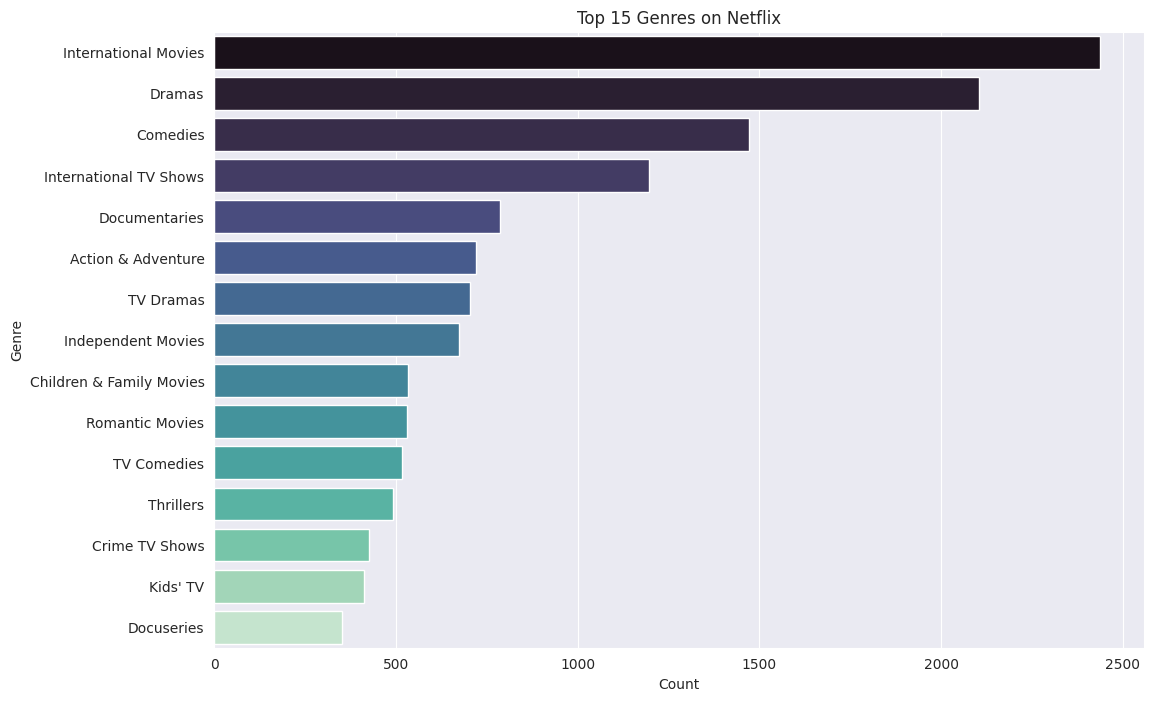

In [ ]:
top_genres_plot = top_genres.head(15)

plt.figure(figsize=(12,8))
sns.barplot(y='genre', x='count', data=top_genres_plot, palette='mako', hue='genre', legend=False)
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

### Outcome - International Movies and Dramas are the top genres

### Practice Q4- What is the distribution of content duration?

In [ ]:
movies_df = df[df['type'] == 'Movie'].copy()
tvshows_df = df[df['type'] == 'TV Show'].copy()

In [ ]:
movies_df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12


In [ ]:
tvshows_df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8


In [ ]:
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)
tvshows_df['seasons'] = tvshows_df['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

In [ ]:
movies_df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_min
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,93


In [ ]:
tvshows_df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,seasons
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,4


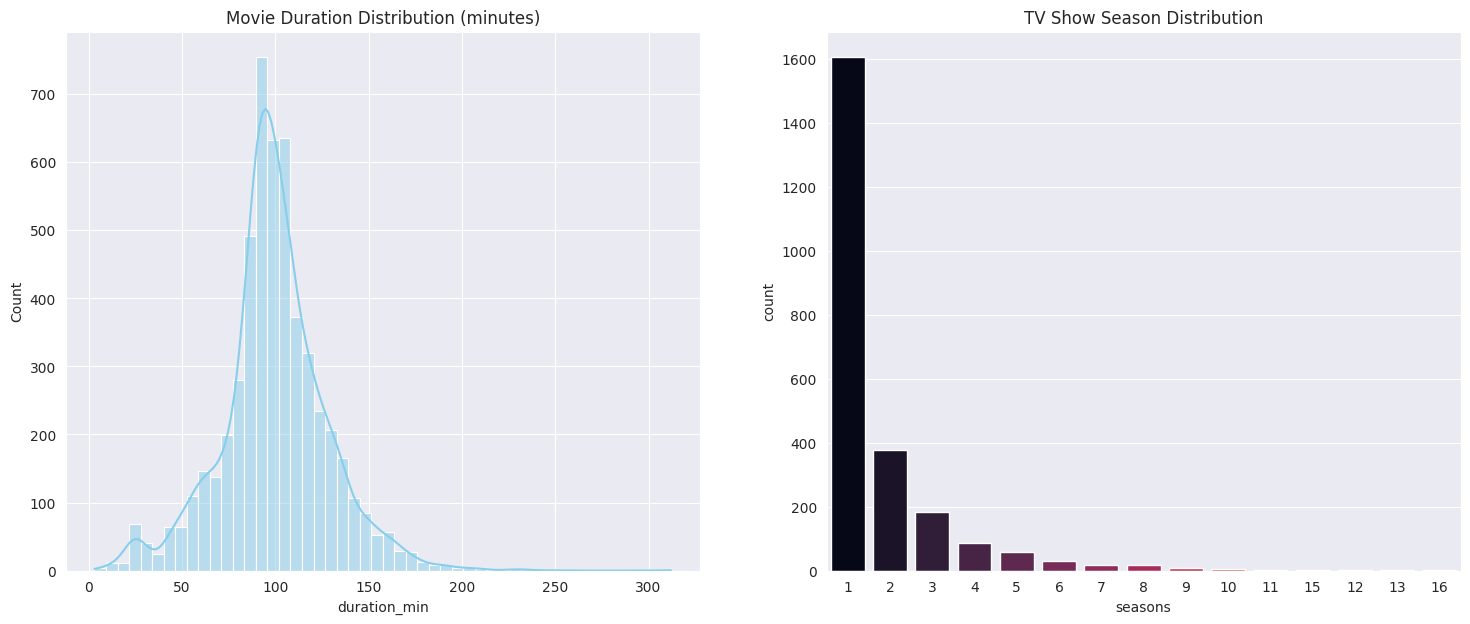

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(18,7))

sns.histplot(ax=axes[0], data=movies_df, x='duration_min', bins=50, kde=True, color='skyblue').set_title('Movie Duration Distribution (minutes)')

sns.countplot(ax=axes[1], x='seasons', data=tvshows_df, palette='rocket', order=tvshows_df['seasons'].value_counts().index, hue='seasons', legend=False).set_title('TV Show Season Distribution')

plt.show()

### Outcome - Majority of movies are in 90 to 120 mins range.
### Only limited shows had seasons continued, mostly had only 1 season

### Practice Q5- Where does the content come from? (Geographical Analysis)

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1


In [ ]:
countries_df = df.assign(country=df['country'].str.split(', ')).explode('country')
countries_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1


In [ ]:
top_countries_counts = countries_df['country'].value_counts().reset_index()
top_countries_counts.columns = ['country', 'count']

In [ ]:
print(top_countries_counts)

             country  count
0      United States   3792
1              India    990
2     United Kingdom    721
3             Canada    412
4             France    349
..               ...    ...
116           Panama      1
117  United Kingdom,      1
118           Uganda      1
119     East Germany      1
120       Montenegro      1

[121 rows x 2 columns]


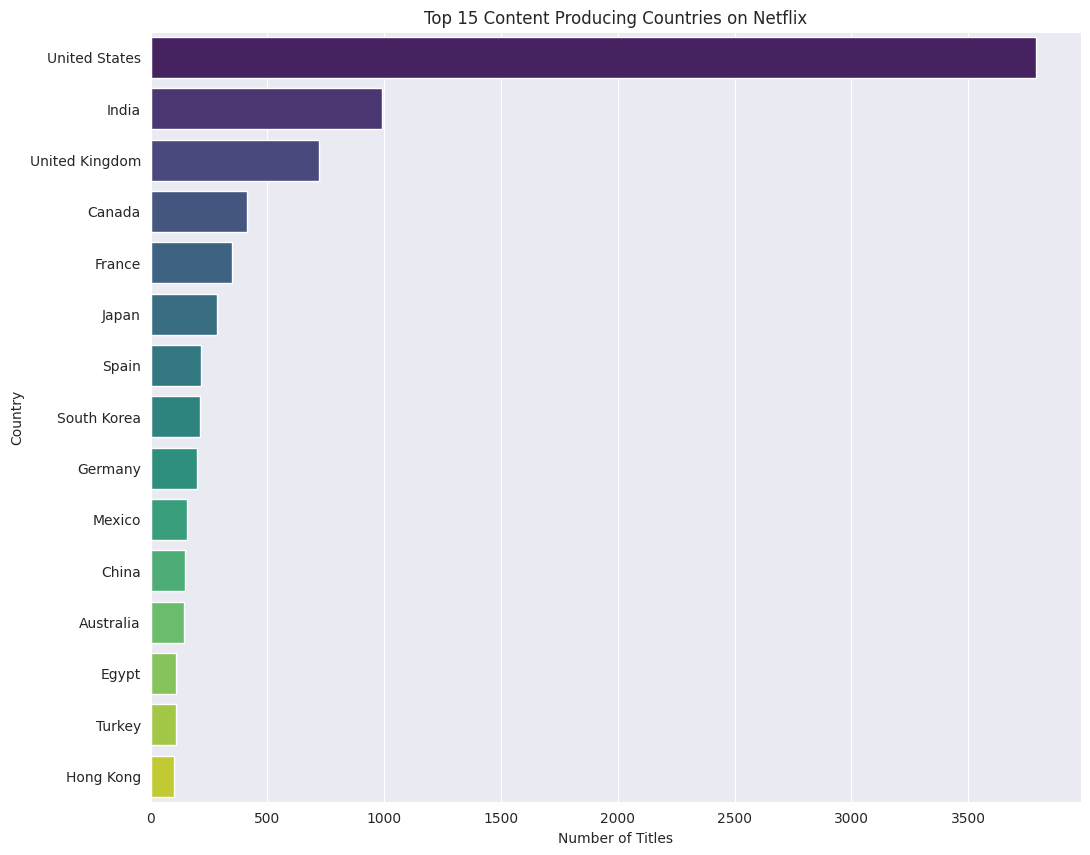

In [ ]:
top_countries_counts_plot = top_countries_counts.head(15)

plt.figure(figsize=(12, 10))
sns.barplot(y='country', x='count', data=top_countries_counts_plot, palette='viridis', hue='country', legend=False)
plt.title('Top 15 Content Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

### Outcome- United States is largest producer of content followed by India

### Practice Q6- What are the maturity ratings of the content?

In [ ]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1


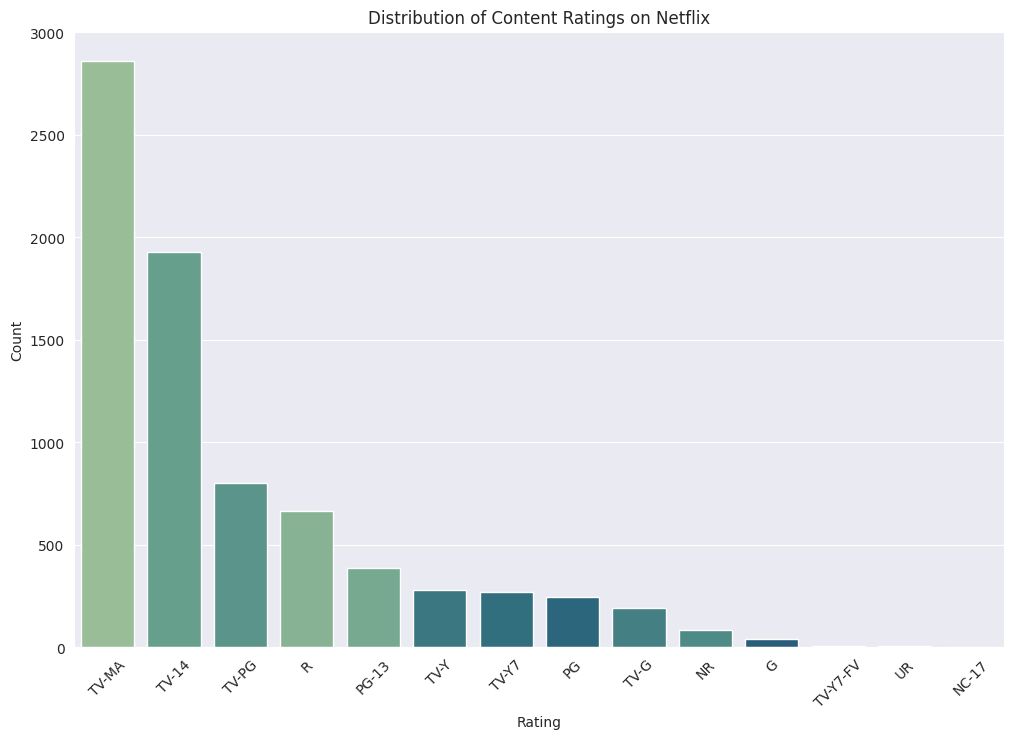

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='crest', hue='rating', legend=False)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Feature Engineering

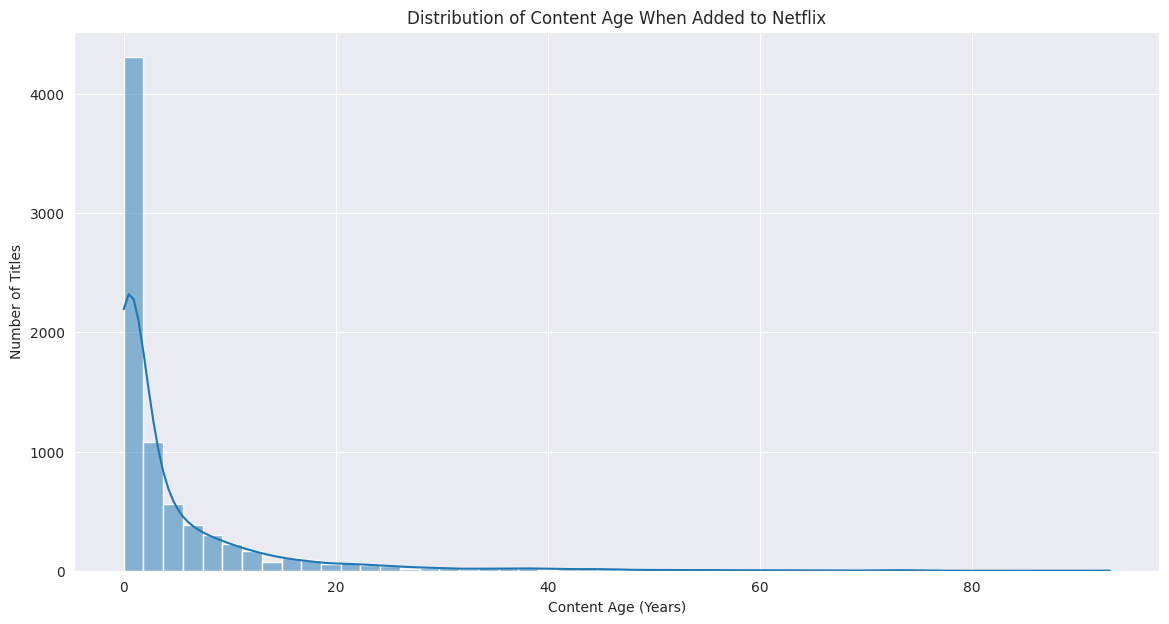

In [ ]:
df['content_age'] = df['year_added'] - df['release_year']

content_age = df[df['content_age'] >= 0]

plt.figure(figsize=(14, 7))
sns.histplot(data=content_age, x='content_age', bins=50, kde=True)
plt.title('Distribution of Content Age When Added to Netflix')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.show()

### Outcome- Large spike at 0 => almost all content was added on netflix the same year it was released

## Deeper multivariate analysis

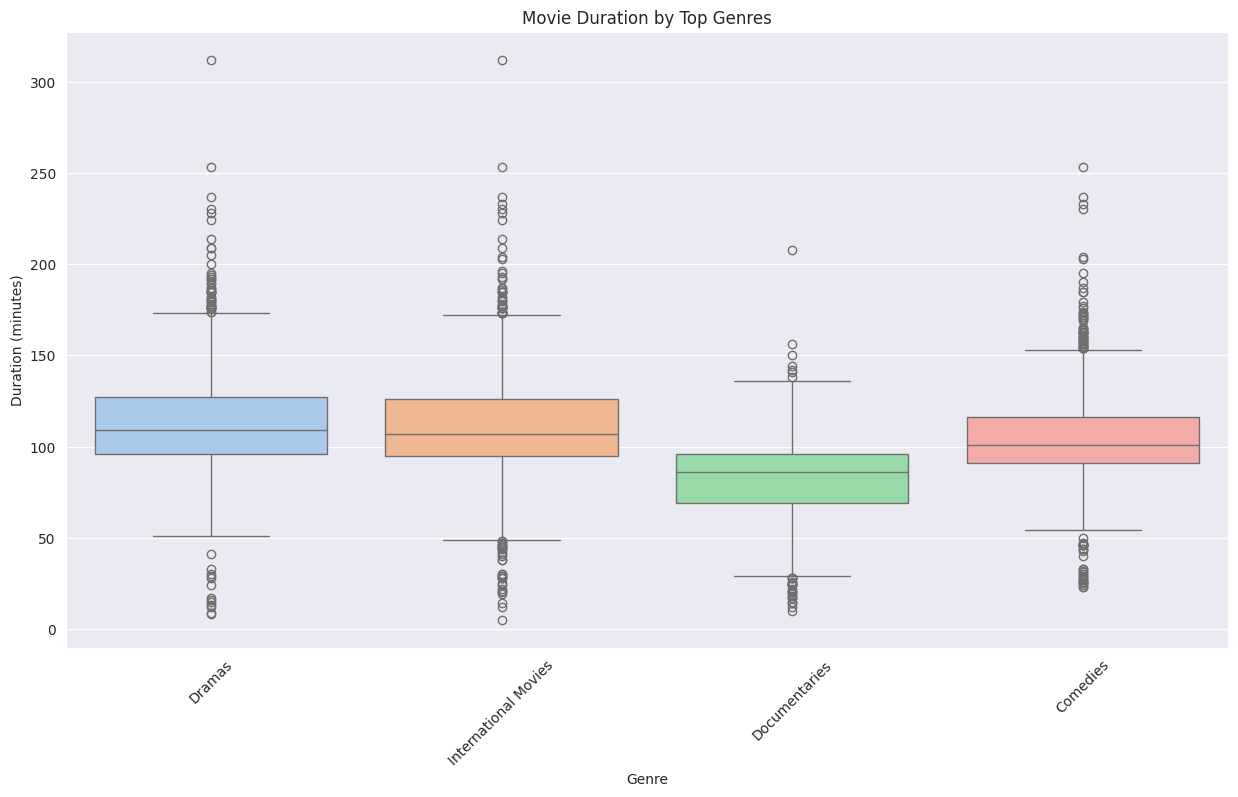

In [ ]:
top_genres = genres_df['genre'].value_counts().index[:5]
genres_movies = genres_df[(genres_df['type'] == 'Movie') & (genres_df['genre'].isin(top_genres))].copy()
genres_movies['duration_min'] = genres_movies['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(15, 8))
sns.boxplot(data=genres_movies, x='genre', y='duration_min', palette='pastel', hue='genre', legend=False)
plt.title('Movie Duration by Top Genres')
plt.xlabel('Genre')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.show()

## Word Cloud from Content Description

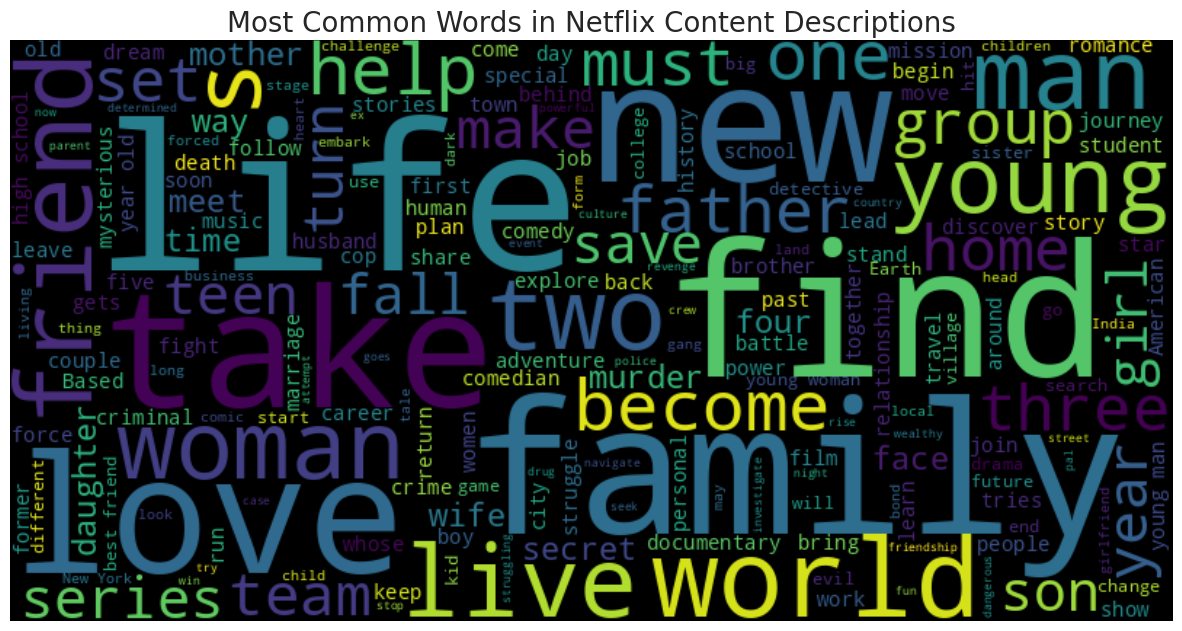

In [ ]:
combined_text = ' '.join(df['description'])

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(combined_text)
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Content Descriptions', fontsize=20)
plt.show()

# Submission Questions

### Q1- How has the distribution of content ratings changed over time?

In [ ]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,content_age
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,0


In [ ]:
df['rating'].value_counts()

,count
rating,
TV-MA,2861
TV-14,1928
TV-PG,804
R,665
PG-13,386
TV-Y,279
TV-Y7,270
PG,247
TV-G,194


In [ ]:
df['rating'].isnull().sum()

np.int64(0)

In [ ]:
content_ratings_overtime = df.groupby(['year_added', 'rating']).size().unstack().fillna(0)

print(content_ratings_overtime.sum())

rating
G             39.0
NC-17          3.0
NR            83.0
PG           247.0
PG-13        386.0
R            665.0
TV-14       1928.0
TV-G         194.0
TV-MA       2861.0
TV-PG        804.0
TV-Y         279.0
TV-Y7        270.0
TV-Y7-FV       6.0
UR             5.0
dtype: float64


<Figure size 1400x800 with 0 Axes>

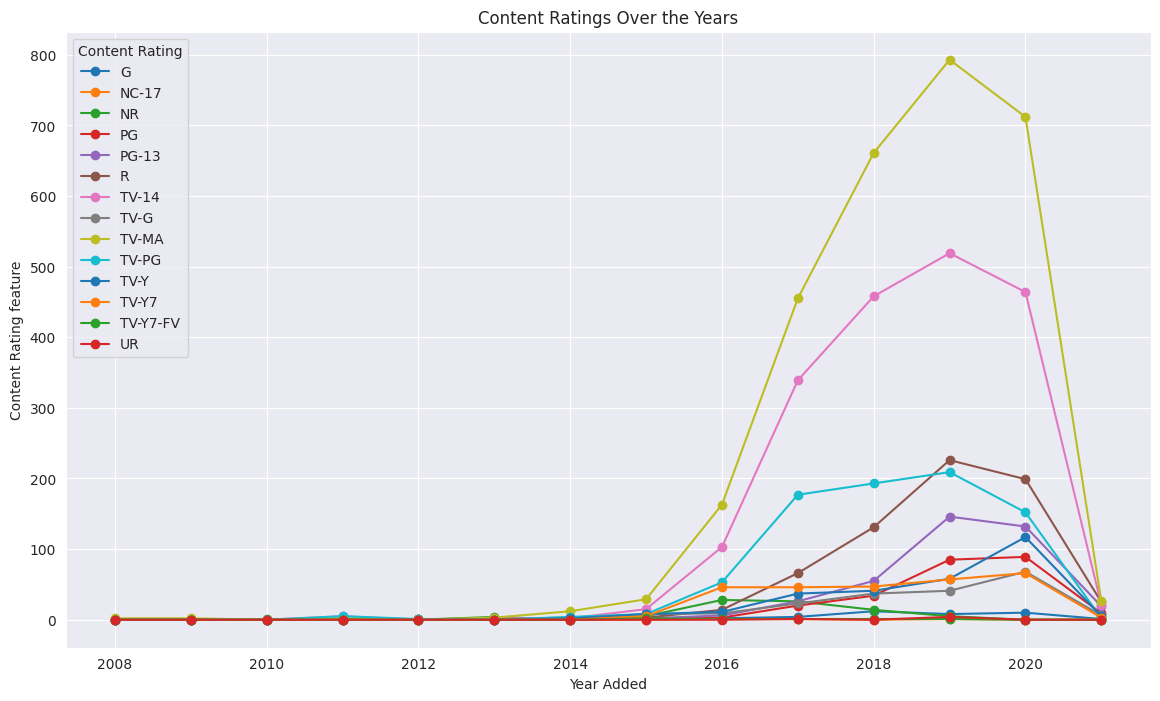

In [ ]:
plt.figure(figsize=(14, 8))
content_ratings_overtime.plot(kind='line', marker='o', figsize=(14, 8))
plt.title('Content Ratings Over the Years')
plt.xlabel('Year Added')
plt.ylabel('Content Rating feature')
plt.legend(title='Content Rating')
plt.grid(True)
plt.show()

### Outcome-
#### TV_MA is the rating given to most content (max 800) during 2016 to 2021
#### Second highest rating category was TV-14 (max 520)
#### Lowest rating given is NC-17 to only 3 contents

### Q2- Is there a relationship between content age and its type (Movie vs. TV Show)?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7770 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   object        
 10  listed_in     7770 non-null   object        
 11  description   7770 non-null   object        
 12  year_added    7770 non-null   int32         
 13  month_added   7770 non-null   int32         
 14  content_age   7770 non-null   int64         
dtypes: datetime64[ns](1), int32(2), int64(2), o

#### Type feature is object, content_age feature is int. Doing Bivariate analysis of Categorical vs Numeric

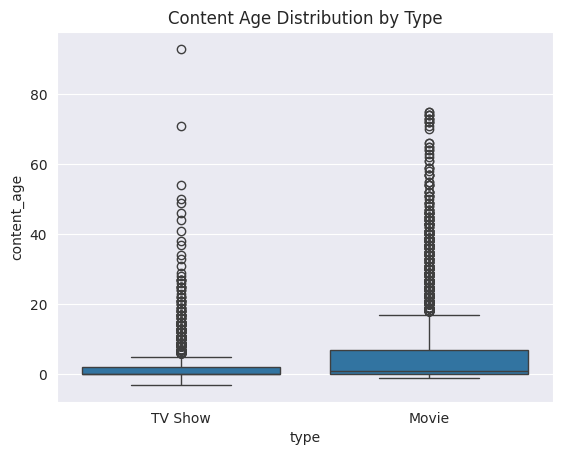

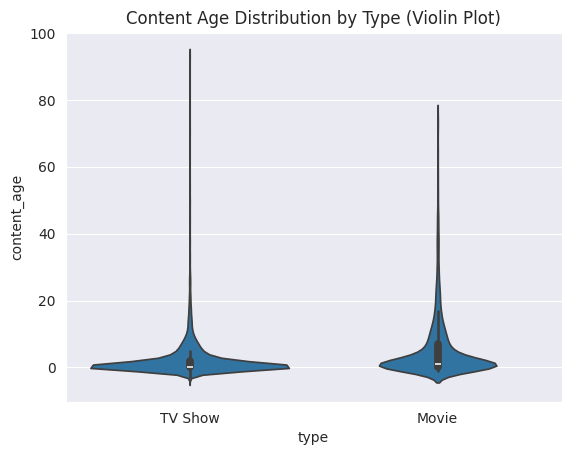

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="type", y="content_age", data=df)
plt.title("Content Age Distribution by Type")
plt.show()

sns.violinplot(x="type", y="content_age", data=df)
plt.title("Content Age Distribution by Type (Violin Plot)")
plt.show()

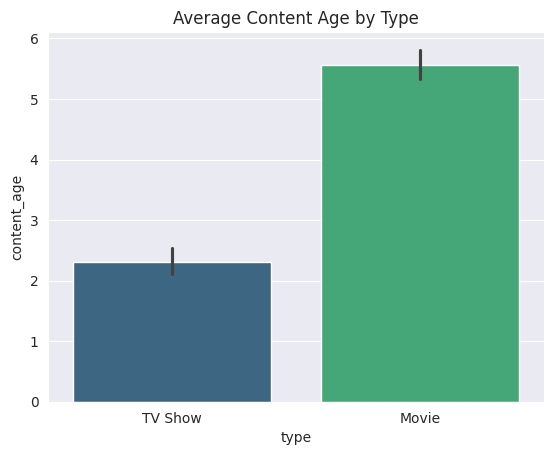

In [ ]:
sns.barplot(x="type", y="content_age", data=df, palette='viridis', hue='type', estimator=lambda x: x.mean())
plt.title("Average Content Age by Type")
plt.show()

### Outcome- TV Shows have newer content age and Movie have older content age

### Q3- Can we identify any trends in content production based on the release year vs. the year added to Netflix?

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,content_age
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12,7
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11,8
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1,12


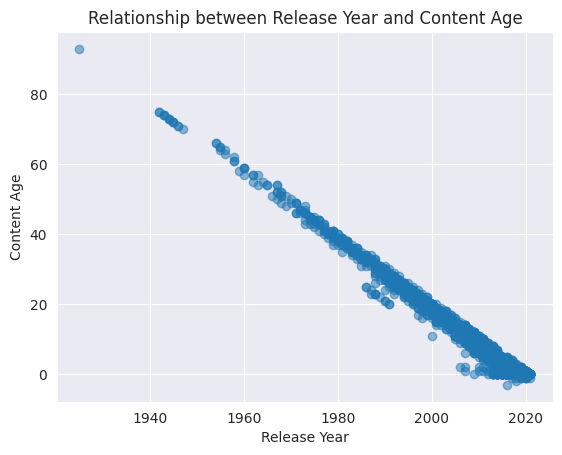

In [ ]:
plt.scatter(df["release_year"], df["content_age"], alpha=0.5)
plt.xlabel("Release Year")
plt.ylabel("Content Age")
plt.title("Relationship between Release Year and Content Age")
plt.show()

In [ ]:
release_year_feature = df['release_year']
year_added_feature = df['year_added']

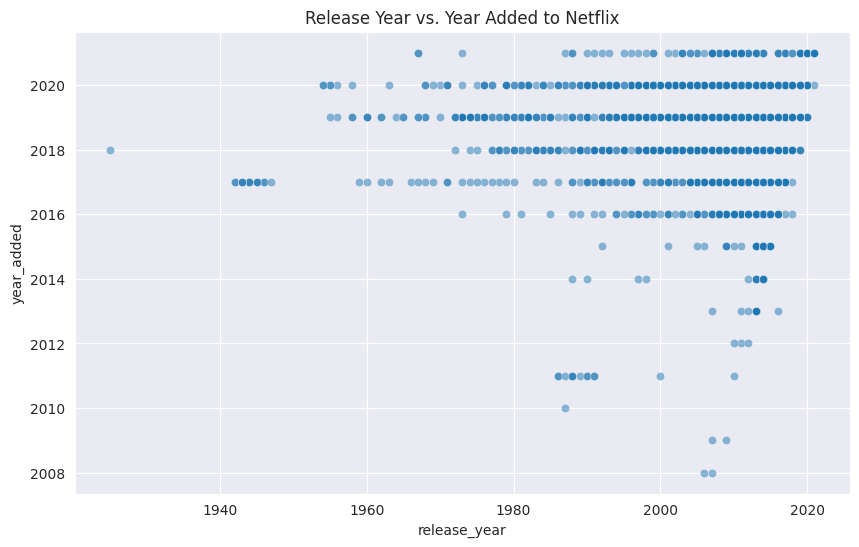

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="release_year", y="year_added", data=df, alpha=0.5)
plt.title("Release Year vs. Year Added to Netflix")
plt.show()

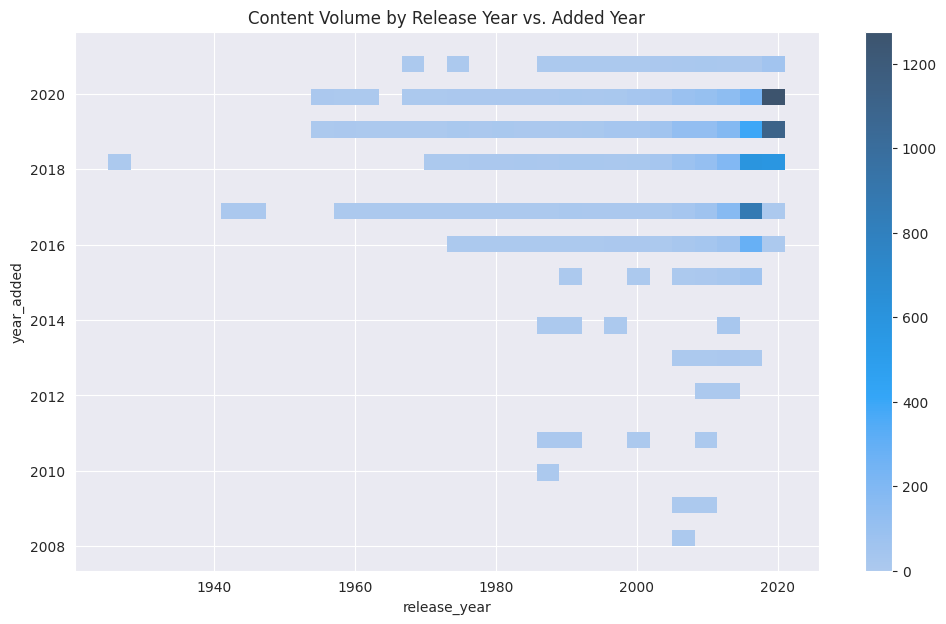

In [ ]:
plt.figure(figsize=(12,7))
sns.histplot(data=df, x="release_year", y="year_added", bins=30, cbar=True)
plt.title("Content Volume by Release Year vs. Added Year")
plt.show()

### Outcome- Older content was initially added on Netflix and also added to Netflix much later after release.
### In latest years, content was quickly added to Netflix as released.

### Q4- What are the most common word pairs or phrases in content descriptions?

In [ ]:
print(df['description'])

0       In a future where the elite inhabit an island ...
1       After a devastating earthquake hits Mexico Cit...
2       When an army recruit is found dead, his fellow...
3       In a postapocalyptic world, rag-doll robots hi...
4       A brilliant group of students become card-coun...
                              ...                        
7782    When Lebanon's Civil War deprives Zozo of his ...
7783    A scrappy but poor boy worms his way into a ty...
7784    In this documentary, South African rapper Nast...
7785    Dessert wizard Adriano Zumbo looks for the nex...
7786    This documentary delves into the mystique behi...
Name: description, Length: 7770, dtype: object


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, bigrams, FreqDist
import string

nltk.download('punkt')
nltk.download("punkt_tab")
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
complete_text = " ".join(df["description"].dropna().astype(str)).lower()

tokens = word_tokenize(complete_text)
tokens = [t for t in tokens if t.isalpha()]
tokens = [t for t in tokens if t not in stopwords.words("english")]

In [ ]:
bigrams_list = list(bigrams(tokens))
print(bigrams_list)

[('future', 'elite'), ('elite', 'inhabit'), ('inhabit', 'island'), ('island', 'paradise'), ('paradise', 'far'), ('far', 'crowded'), ('crowded', 'slums'), ('slums', 'get'), ('get', 'one'), ('one', 'chance'), ('chance', 'join'), ('join', 'saved'), ('saved', 'squalor'), ('squalor', 'devastating'), ('devastating', 'earthquake'), ('earthquake', 'hits'), ('hits', 'mexico'), ('mexico', 'city'), ('city', 'trapped'), ('trapped', 'survivors'), ('survivors', 'walks'), ('walks', 'life'), ('life', 'wait'), ('wait', 'rescued'), ('rescued', 'trying'), ('trying', 'desperately'), ('desperately', 'stay'), ('stay', 'alive'), ('alive', 'army'), ('army', 'recruit'), ('recruit', 'found'), ('found', 'dead'), ('dead', 'fellow'), ('fellow', 'soldiers'), ('soldiers', 'forced'), ('forced', 'confront'), ('confront', 'terrifying'), ('terrifying', 'secret'), ('secret', 'haunting'), ('haunting', 'jungle'), ('jungle', 'island'), ('island', 'training'), ('training', 'camp'), ('camp', 'postapocalyptic'), ('postapocalyp

In [ ]:
bigram_freq = FreqDist(bigrams_list)
print(bigram_freq.most_common(20))

[(('high', 'school'), 131), (('young', 'man'), 105), (('young', 'woman'), 98), (('new', 'york'), 86), (('best', 'friend'), 50), (('true', 'story'), 49), (('best', 'friends'), 45), (('world', 'war'), 44), (('based', 'true'), 42), (('documentary', 'follows'), 38), (('los', 'angeles'), 38), (('falls', 'love'), 37), (('war', 'ii'), 36), (('york', 'city'), 35), (('around', 'world'), 35), (('documentary', 'series'), 35), (('road', 'trip'), 32), (('serial', 'killer'), 32), (('two', 'young'), 29), (('young', 'boy'), 28)]


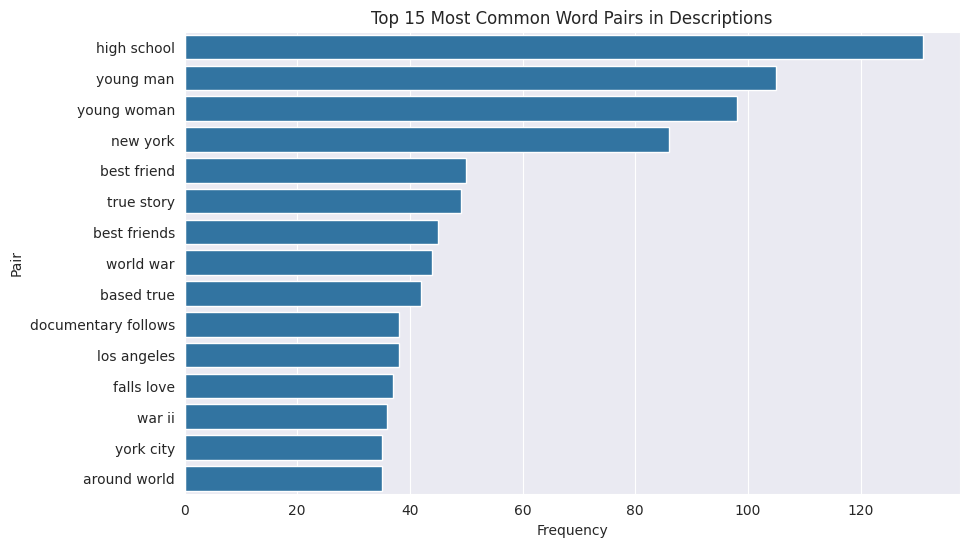

In [ ]:
pairs_df = pd.DataFrame(bigram_freq.most_common(15), columns=["Pair", "Frequency"])
pairs_df["Pair"] = pairs_df["Pair"].apply(lambda x: " ".join(x))
plt.figure(figsize=(10,6))
sns.barplot(x="Frequency", y="Pair", data=pairs_df)
plt.title("Top 15 Most Common Word Pairs in Descriptions")
plt.show()

### Outcome- Most common word pair is 'high school'

### Q5- Who are the top directors on Netflix?

In [ ]:
df['director'].value_counts()

,count
director,
Unknown,2376
"Raúl Campos, Jan Suter",18
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
...,...
John Trengove,1
Jonathan Helpert,1
Jacob Schwab,1


In [ ]:
all_directors = df['director'].str.split(",").explode().str.strip()
print(all_directors)

0                 Unknown
1       Jorge Michel Grau
2            Gilbert Chan
3             Shane Acker
4          Robert Luketic
              ...        
7782          Josef Fares
7783          Mozez Singh
7784              Unknown
7785              Unknown
7786             Sam Dunn
Name: director, Length: 8487, dtype: object


In [ ]:
top_directors = all_directors.value_counts().head()
print(top_directors)

director
Unknown         2376
Jan Suter         21
Raúl Campos       19
Marcus Raboy      16
Jay Karas         15
Name: count, dtype: int64


### Outcome- Most are Unknow. After this, the top director is 'Jan Suter'